In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib as mpl
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
try:
    from cellacdc import cca_functions
    from cellacdc import myutils
except FileNotFoundError:
    # Check if user has developer version --> add the Cell_ACDC/cellacdc
    # folder to path and import from thre
    sys.path.insert(0, '../cellacdc/')
    from cellacdc import cca_functions
    from cellacdc import myutils

In [2]:
#for computer
overall_df = pd.read_csv(r"Y:\Analysed Live cell microscopy data\11122024\rep3_final_processed_combined_fluorescence_analysis_dataset.csv")


C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_11348\274277845.py:2: DtypeWarning: Columns (52) have mixed types. Specify dtype option on import or set low_memory=False.
  overall_df = pd.read_csv(r"Y:\Analysed Live cell microscopy data\11122024\rep3_final_processed_combined_fluorescence_analysis_dataset.csv")


In [3]:
complete_cycles = overall_df[overall_df['complete_cycle_sa'] == 1]
display(overall_df.rep.unique())
display(len(complete_cycles.f_pos_cell_id_sa.unique()))

pos_len= 0
for rep in ((overall_df['rep']).unique()):
    rep_df = overall_df[overall_df['rep'] == rep]
    for strain in ((rep_df['strain_sa']).unique()):
        strain_df = rep_df[rep_df['strain_sa'] == strain]
        display(rep, strain, strain_df.Position_n.unique())
        pos_len =pos_len + len(strain_df.Position_n.unique())
display(pos_len)

array([3], dtype=int64)

967

3

'YCY024_1_WTlabelled'

array(['Position_1', 'Position_2', 'Position_3', 'Position_6'],
      dtype=object)

...

array(['Position_15', 'Position_16', 'Position_17', 'Position_18',
       'Position_21'], dtype=object)

3

'YCY038_1_Whi5Bck2doubledel_labelled'

array(['Position_22', 'Position_23', 'Position_24', 'Position_28'],
      dtype=object)

17

# ***for each complete pre-switch cell cycle, calculate time relative to bud emergence*** 

In [4]:
complete_preswitch_cycles = overall_df[(overall_df['growthmedium_sa'] == "SCD")
                            & (overall_df['cycle_saw_switch_sa'] == False)
                            & (overall_df['complete_cycle_sa'] == True)
                            & (overall_df['relationship_sa'] != "bud")]

complete = []
import warnings

with warnings.catch_warnings(record=True):
    for rep in complete_preswitch_cycles['rep'].unique():
        rep_df = complete_preswitch_cycles[complete_preswitch_cycles['rep'] == rep]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            cycle_df.sort_values(by=['frame_i'], inplace = True)

            S_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "S"]
            S_df.sort_values(by=['frame_i'], inplace = True)
            bud_emerg_frame = S_df.frame_i.min() 
            cycle_df['bud_emerg_frame'] = bud_emerg_frame 

            for frame in cycle_df['frame_i'].unique():
                frame_ind = (cycle_df[cycle_df['frame_i'] == frame]).index 
                cycle_df.loc[frame_ind[0], 'frame_rel_to_bud_emergence'] = frame - bud_emerg_frame 

            complete.append(cycle_df)



new_complete_preswitch_cycles_df = pd.concat(complete).reset_index(drop = True)
new_complete_preswitch_cycles_df['time_rel_to_bud_emergence_mins'] = new_complete_preswitch_cycles_df['frame_rel_to_bud_emergence']*3
          
        
        

# ***for pre-switch complete cycles, plot histone cellular amount and whi5 nuclear mean pixel intensity on same plot*** 

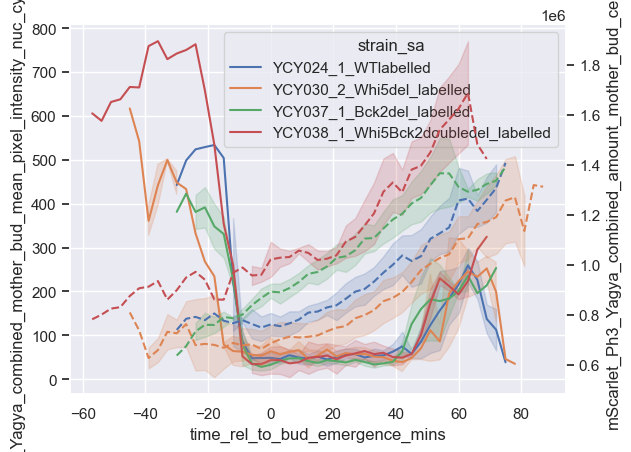

In [5]:
#plot whi5 nuclear intensity

a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted",
                hue = "strain_sa", 
                #kind ="line", 
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"],
                #height=8, 
                #aspect=1.5
                )
#a.set_axis_labels("Time relative to bud emergence (mins)", "Whi5_WIQ_mCitrine nuclear mean pixel intensity (bkgr_adjusted)", size = 15)

#create second x-axis on right side
ax2 = plt.twinx()

#plot histone cellular amount

a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_combined_amount_mother_bud_cell",
                hue = "strain_sa", 
                #kind ="line", 
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"],
                #height=8, 
                #aspect=1.5,
                linestyle ='--',
                 legend = False,
                ax=ax2)
plt.grid()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

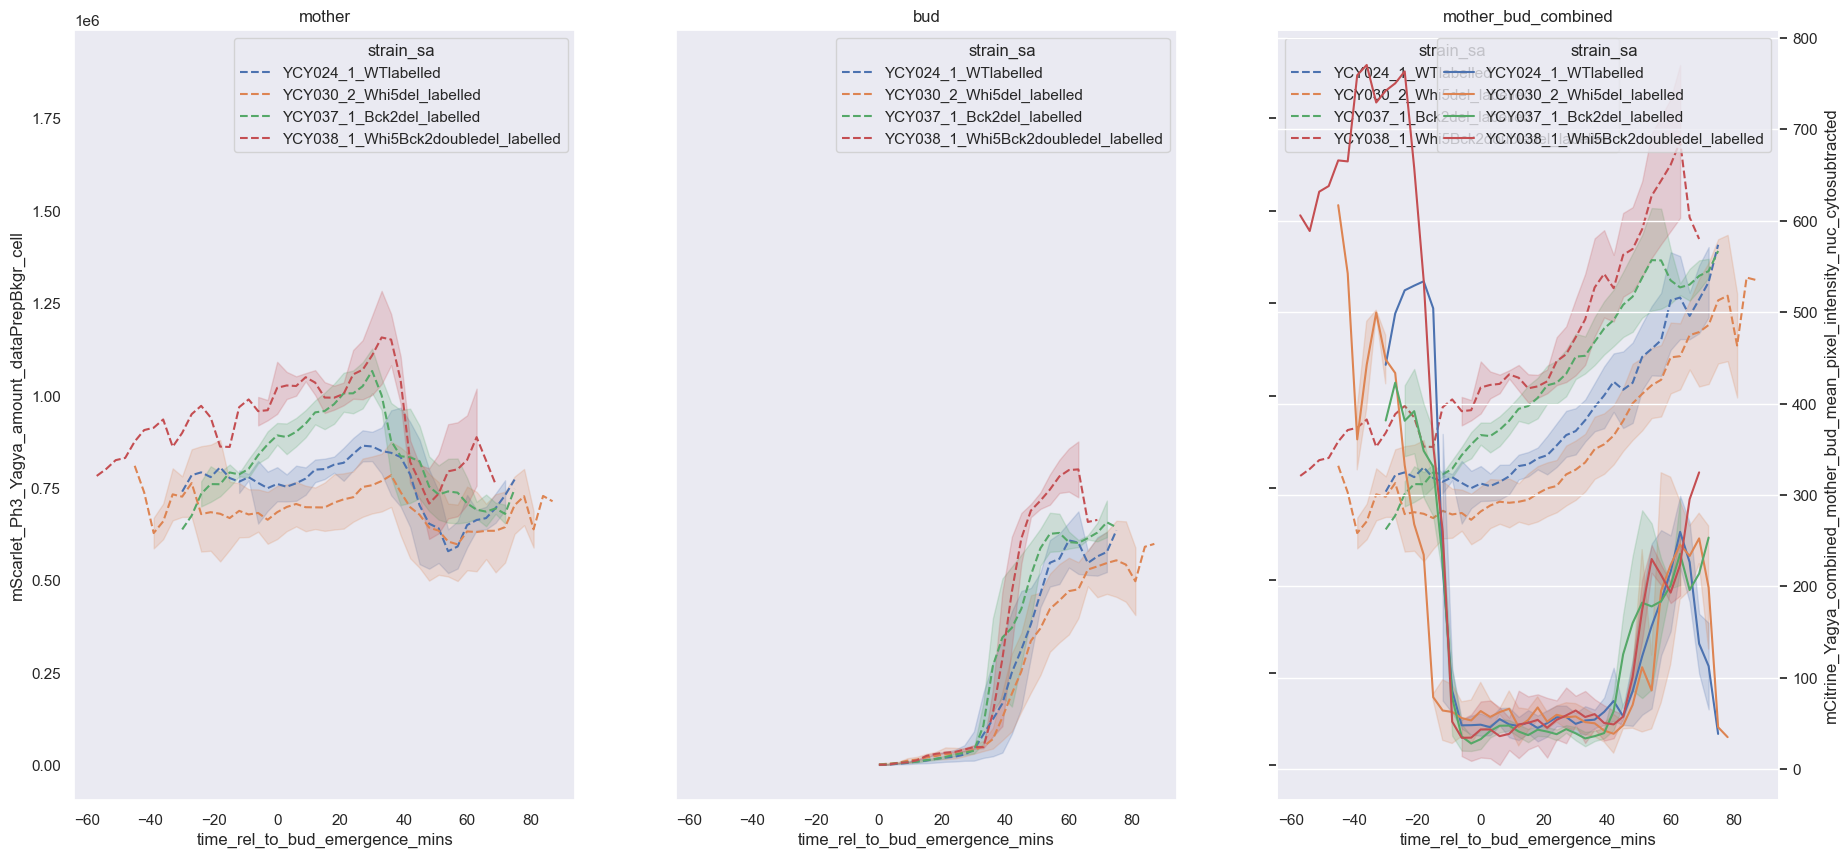

In [6]:
f, ((ax1),(ax2), (ax3)) = plt.subplots(nrows=1, ncols=3, figsize=(22, 10), sharey = True, sharex= True)
f= sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell_rel",
                hue = "strain_sa", 
                #kind ="scatter",
                ax = ax2,
                linestyle ='--',
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"])
f.grid()

f = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell",
                hue = "strain_sa", 
#                style = "custom_G1_stage",
                #kind ="scatter",
                ax = ax1,
                linestyle ='--',
                color = "green",
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"]
                )
f.grid()
f = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_combined_amount_mother_bud_cell",
                hue = "strain_sa", 
                #kind ="scatter",
                ax = ax3,
                color = "green",
                linestyle ='--',
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"]
                )
f.grid()
ax3 = plt.twinx()

f= sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted",
                hue = "strain_sa", 
                #kind ="scatter",
                ax = ax3,
                data =new_complete_preswitch_cycles_df[new_complete_preswitch_cycles_df['strain_sa'] != "MMY"])
ax1.set_title("mother")
ax2.set_title("bud")
ax3.set_title("mother_bud_combined")
#a.set_axis_labels("Time in cell cycle (mins)", "rel_mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell", size = 15)

plt.show

# ***find cell cycle ids of complete first G1s of first daughters of S/G2/M switchers*** 

In [7]:
ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ].f_pos_cell_id_sa.unique()



# ***find cell cycle ids of mothers of these daughters^*** 

In [8]:
import warnings

switch_mums = []
with warnings.catch_warnings(record=True):
     for rep in overall_df['rep'].unique():
        rep_df = overall_df[(overall_df['rep'] == rep) & (overall_df['strain_sa'] != "MMY")]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            if cellcycle in ids_first_S_daughters:
                
                cell = cycle_df['Cell_ID'].iloc[0]
                pos = cycle_df['Position_n'].iloc[0]
                strain = cycle_df['strain_sa'].iloc[0] 
                rep = cycle_df['rep'].iloc[0]
                #display(cellcycle)
                
                G1_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "G1"]
                if len(G1_df) > 0:
                    mother_id = G1_df['relative_ID'].iloc[0]
                    #display(mother_id, rep, strain, pos)
                    mother_switch_df = rep_df[(rep_df['rep'] == rep) &
                                    (rep_df['strain_sa'] == strain) &
                                    (rep_df['Position_n'] == pos) &
                                    (rep_df['Cell_ID'] == mother_id) &
                                    (rep_df['cycle_saw_switch_sa'] == True) 
                                   ]
                    switch_mums.append(mother_switch_df.f_pos_cell_id_sa.iloc[0])

# ***get cell cycle ids of all mothers at switch, regardless of whether they or their daughters have complete cycles*** 

In [9]:
moms_frame50_df = overall_df[(overall_df['cell_cycle_stage_sa'] == "S") &
                                     (overall_df['frame_i'] == 50) &
                                     (overall_df['relationship'] == "mother")]
moms_frame50_ids = moms_frame50_df.f_pos_cell_id_sa.unique().tolist()

# ***for both mothers with complete daughters (switch_mums) and mothers with imcomplete daughters (switch_mums_not_covered_in_complete_daughter_analysis), plot Whi5 signal curve***
# ***using the hover function from mplcursors, manually determine frame of Whi5 re-entry into nucleus for both sets of mothers*** 

In [13]:
%pip install mplcursors
from mplcursors import cursor

Note: you may need to restart the kernel to use updated packages.


In [14]:
display(len(moms_frame50_ids))
display(len(switch_mums))
display(len(list(set(moms_frame50_ids) - set(switch_mums))))
switch_mums_not_covered_in_complete_daughter_analysis = list(set(moms_frame50_ids) - set(switch_mums))

66

46

20

In [41]:
#display((switch_mums[40:]))
# display(switch_mums_not_covered_in_complete_daughter_analysis[15:])

['YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_3',
 'YCY024_1_WTlabelled_Position_2_Cell_17_Gen_1_Rep_3',
 'YCY030_2_Whi5del_labelled_Position_9_Cell_1_Gen_4_Rep_3',
 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_16_Gen_1_Rep_3',
 'YCY030_2_Whi5del_labelled_Position_9_Cell_6_Gen_1_Rep_3']

In [42]:
# %matplotlib qt 

# current_cohort = switch_mums_not_covered_in_complete_daughter_analysis[15:]
# data = overall_df[overall_df['f_pos_cell_id_sa'].isin(current_cohort)].reset_index(drop = True)
# a = sns.relplot( kind = "scatter",
#             data = data, 
#             x = "frame_i", 
#             y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted", 
#             col  = "f_pos_cell_id_sa",
#             col_order =[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_3',
#  'YCY024_1_WTlabelled_Position_2_Cell_17_Gen_1_Rep_3',
#  'YCY030_2_Whi5del_labelled_Position_9_Cell_1_Gen_4_Rep_3',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_16_Gen_1_Rep_3',
#  'YCY030_2_Whi5del_labelled_Position_9_Cell_6_Gen_1_Rep_3'],
#             hue = "cell_cycle_stage_sa",
#             col_wrap = 2)
    

# cursor(hover = True)
# plt.show()

# ***record manually determined first frame of whi5 nuclear reentry as list***

In [43]:
### manually determine frame of whi5 re-entry into nuclei of sg2m switchers with complete daughters

manually_annotated_whi5_reentry_s_switchers_complete_daughters =  [
[ 'YCY024_1_WTlabelled_Position_1_Cell_4_Gen_4_Rep_3',42],
[ 'YCY024_1_WTlabelled_Position_1_Cell_2_Gen_3_Rep_3',61],
[ 'YCY024_1_WTlabelled_Position_1_Cell_6_Gen_1_Rep_3',158],
[ 'YCY024_1_WTlabelled_Position_1_Cell_10_Gen_1_Rep_3',164],
[ 'YCY024_1_WTlabelled_Position_1_Cell_1_Gen_3_Rep_3',189],
[ 'YCY024_1_WTlabelled_Position_2_Cell_1_Gen_1_Rep_3',73],
[ 'YCY024_1_WTlabelled_Position_3_Cell_3_Gen_1_Rep_3',45],
[ 'YCY024_1_WTlabelled_Position_3_Cell_1_Gen_3_Rep_3',53],
[ 'YCY024_1_WTlabelled_Position_3_Cell_2_Gen_3_Rep_3',95],
[ 'YCY024_1_WTlabelled_Position_6_Cell_2_Gen_2_Rep_3',40],
[ 'YCY024_1_WTlabelled_Position_6_Cell_3_Gen_3_Rep_3',45],
[ 'YCY024_1_WTlabelled_Position_6_Cell_1_Gen_3_Rep_3',77],
[ 'YCY024_1_WTlabelled_Position_6_Cell_13_Gen_1_Rep_3',128],
[ 'YCY024_1_WTlabelled_Position_6_Cell_5_Gen_4_Rep_3',159],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_1_Gen_1_Rep_3',43],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_4_Gen_1_Rep_3',48],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_3_Gen_4_Rep_3',159],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_5_Gen_1_Rep_3',171],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_2_Gen_3_Rep_3',42],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_5_Gen_1_Rep_3',48],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_3_Gen_2_Rep_3',130],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_7_Gen_1_Rep_3',155],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_1_Gen_3_Rep_3', np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_5_Gen_1_Rep_3',62],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_3_Gen_3_Rep_3',119],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_4_Gen_4_Rep_3',70],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_10_Gen_1_Rep_3',111],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_6_Gen_1_Rep_3',144],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_4_Gen_1_Rep_3',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_2_Gen_1_Rep_3',41],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_14_Gen_1_Rep_3',168],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_18_Gen_1_Rep_3',134],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_2_Gen_3_Rep_3',48],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_5_Gen_1_Rep_3',113],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_6_Gen_3_Rep_3',43],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_4_Gen_3_Rep_3',147],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_3_Gen_1_Rep_3',45],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_1_Gen_4_Rep_3',47],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_2_Gen_3_Rep_3',49],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_19_Gen_1_Rep_3',117],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_1_Gen_3_Rep_3', np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_2_Gen_1_Rep_3',106],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_2_Gen_3_Rep_3',41],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_1_Gen_1_Rep_3',158],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_1_Gen_3_Rep_3',43],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_10_Gen_1_Rep_3',66]
]

### manually determine frame of whi5 re-entry into nuclei of sg2m switchers for incomplete s switchers or ones with incomplete daughters

manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters =  [
['YCY037_1_Bck2del_labelled_Position_16_Cell_2_Gen_4_Rep_3',155],
 ['YCY024_1_WTlabelled_Position_1_Cell_3_Gen_2_Rep_3',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_4_Gen_3_Rep_3',53],
 ['YCY024_1_WTlabelled_Position_6_Cell_14_Gen_1_Rep_3',np.nan],
[ 'YCY024_1_WTlabelled_Position_2_Cell_2_Gen_4_Rep_3',94],
 ['YCY037_1_Bck2del_labelled_Position_18_Cell_9_Gen_1_Rep_3',88],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_4_Gen_3_Rep_3',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_5_Gen_3_Rep_3',100],
[ 'YCY024_1_WTlabelled_Position_1_Cell_5_Gen_1_Rep_3',np.nan],
 ['YCY037_1_Bck2del_labelled_Position_15_Cell_1_Gen_4_Rep_3',45],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_1_Gen_3_Rep_3',41],
 ['YCY037_1_Bck2del_labelled_Position_15_Cell_9_Gen_1_Rep_3',np.nan],
 ['YCY037_1_Bck2del_labelled_Position_18_Cell_7_Gen_1_Rep_3',44],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_3_Gen_4_Rep_3',113],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_7_Gen_1_Rep_3',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_3',180],
[ 'YCY024_1_WTlabelled_Position_2_Cell_17_Gen_1_Rep_3',np.nan],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_1_Gen_4_Rep_3',np.nan],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_16_Gen_1_Rep_3',80],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_6_Gen_1_Rep_3', np.nan]
]




# ***make df from this list and add this info to overall_df***

In [44]:
# make df from above lists

manually_annotated_whi5_reentry_s_switchers_df = pd.DataFrame(manually_annotated_whi5_reentry_s_switchers_complete_daughters, 
                                                              columns = ['f_pos_cell_id_sa', 'first_postmitotic_frame_manual'] )

manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df = pd.DataFrame(manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters, 
                                                              columns = ['f_pos_cell_id_sa', 'first_postmitotic_frame_manual'] )

In [45]:
### add this whi5-reentry-frame info to overall_df

for cycle in manually_annotated_whi5_reentry_s_switchers_df.f_pos_cell_id_sa.unique():
    whi5_reentry_frame = manually_annotated_whi5_reentry_s_switchers_df.loc[(manually_annotated_whi5_reentry_s_switchers_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual'] = whi5_reentry_frame.iloc[0]
    


### merge df 

for cycle in manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df.f_pos_cell_id_sa.unique():
    whi5_reentry_frame = manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df.loc[(manually_annotated_whi5_reentry_s_switchers_incomplete_or_incomplete_daughters_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_postmitotic_frame_manual'] = whi5_reentry_frame.iloc[0]
    

    

# ***based on whi5 reentry frame, split and label S-phase into postMitotic and notPostMitotic***

In [46]:

overall_df['custom_S_postmitoticstage_manual'] = np.nan



list_for_appending = []
with warnings.catch_warnings(record=True):
    for cellcycle in overall_df['f_pos_cell_id_sa'].unique():
        cycle_df = overall_df[overall_df['f_pos_cell_id_sa'] == cellcycle]
        if cellcycle in moms_frame50_ids:
            first_postmitotic_frame_manual = cycle_df['first_postmitotic_frame_manual'].iloc[0]
            if np.isnan(first_postmitotic_frame_manual) == False:
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] >= first_postmitotic_frame_manual), 'custom_S_postmitoticstage_manual'] = "postMitotic"
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] < first_postmitotic_frame_manual), 'custom_S_postmitoticstage_manual'] = "notPostMitotic"
            
        list_for_appending.append(cycle_df)
            
overall_df = pd.concat(list_for_appending).reset_index(drop = True)                        

                    

# ***for both mothers with complete daughters (switch_mums) and mothers with imcomplete daughters (switch_mums_not_covered_in_complete_daughter_analysis), plot HTB2 signal in the bud***
# ***using the hover function from mplcursors, manually determine frame of HTB2 entry into bud for both sets of mothers*** 

In [72]:
#display((switch_mums[40:]))
#display(switch_mums_not_covered_in_complete_daughter_analysis[15:])

['YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_3',
 'YCY024_1_WTlabelled_Position_2_Cell_17_Gen_1_Rep_3',
 'YCY030_2_Whi5del_labelled_Position_9_Cell_1_Gen_4_Rep_3',
 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_16_Gen_1_Rep_3',
 'YCY030_2_Whi5del_labelled_Position_9_Cell_6_Gen_1_Rep_3']

In [73]:
# %matplotlib qt 

# current_cohort = switch_mums_not_covered_in_complete_daughter_analysis[15:]
# data = overall_df[overall_df['f_pos_cell_id_sa'].isin(current_cohort)].reset_index(drop = True)
# a = sns.relplot( kind = "scatter",
#             data = data, 
#             x = "frame_i", 
#             y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell_rel", 
#             col  = "f_pos_cell_id_sa",
#             col_order =['YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_3',
#  'YCY024_1_WTlabelled_Position_2_Cell_17_Gen_1_Rep_3',
#  'YCY030_2_Whi5del_labelled_Position_9_Cell_1_Gen_4_Rep_3',
#  'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_16_Gen_1_Rep_3',
#  'YCY030_2_Whi5del_labelled_Position_9_Cell_6_Gen_1_Rep_3'],
#             hue = "cell_cycle_stage_sa",
#             col_wrap = 2)
    

# cursor(hover = True)
# plt.show()

# ***record manually determined first frame of HTB2 bud entry as list***

In [74]:



### manually assigning histone entry into buds of sg2m switchers

manually_annotated_hist_entry_buds_of_s_switchers = [
[ 'YCY024_1_WTlabelled_Position_1_Cell_4_Gen_4_Rep_3',39],
[ 'YCY024_1_WTlabelled_Position_1_Cell_2_Gen_3_Rep_3',44],
[ 'YCY024_1_WTlabelled_Position_1_Cell_6_Gen_1_Rep_3',152],
[ 'YCY024_1_WTlabelled_Position_1_Cell_10_Gen_1_Rep_3',159],
[ 'YCY024_1_WTlabelled_Position_1_Cell_1_Gen_3_Rep_3',183],
[ 'YCY024_1_WTlabelled_Position_2_Cell_1_Gen_1_Rep_3',np.nan],
[ 'YCY024_1_WTlabelled_Position_3_Cell_3_Gen_1_Rep_3',41],
[ 'YCY024_1_WTlabelled_Position_3_Cell_1_Gen_3_Rep_3',40],
[ 'YCY024_1_WTlabelled_Position_3_Cell_2_Gen_3_Rep_3',89],
[ 'YCY024_1_WTlabelled_Position_6_Cell_2_Gen_2_Rep_3',36],
[ 'YCY024_1_WTlabelled_Position_6_Cell_3_Gen_3_Rep_3',42],
[ 'YCY024_1_WTlabelled_Position_6_Cell_1_Gen_3_Rep_3',72],
[ 'YCY024_1_WTlabelled_Position_6_Cell_13_Gen_1_Rep_3',122],
[ 'YCY024_1_WTlabelled_Position_6_Cell_5_Gen_4_Rep_3',150],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_1_Gen_1_Rep_3',38],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_4_Gen_1_Rep_3',41],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_3_Gen_4_Rep_3',149],
[ 'YCY030_2_Whi5del_labelled_Position_8_Cell_5_Gen_1_Rep_3',158],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_2_Gen_3_Rep_3',39],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_5_Gen_1_Rep_3',41],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_3_Gen_2_Rep_3',124],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_7_Gen_1_Rep_3',148],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_1_Gen_3_Rep_3', 39],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_5_Gen_1_Rep_3',54],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_3_Gen_3_Rep_3',112],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_4_Gen_4_Rep_3',61],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_10_Gen_1_Rep_3',104],
[ 'YCY030_2_Whi5del_labelled_Position_10_Cell_6_Gen_1_Rep_3',136],
[ 'YCY030_2_Whi5del_labelled_Position_14_Cell_4_Gen_1_Rep_3',38],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_2_Gen_1_Rep_3',38],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_14_Gen_1_Rep_3',159],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_18_Gen_1_Rep_3',128],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_2_Gen_3_Rep_3',43],
[ 'YCY037_1_Bck2del_labelled_Position_17_Cell_5_Gen_1_Rep_3',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_6_Gen_3_Rep_3',39],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_4_Gen_3_Rep_3',141],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_3_Gen_1_Rep_3',39],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_1_Gen_4_Rep_3',41],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_2_Gen_3_Rep_3',41],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_19_Gen_1_Rep_3',112],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_1_Gen_3_Rep_3',39 ],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_2_Gen_1_Rep_3',98],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_2_Gen_3_Rep_3',37],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_1_Gen_1_Rep_3',153],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_1_Gen_3_Rep_3',40],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_10_Gen_1_Rep_3',61]
]

### manually histone entry into buds for incomplete s switchers or ones with incomplete daughters

manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters =   [
['YCY037_1_Bck2del_labelled_Position_16_Cell_2_Gen_4_Rep_3',151],
 ['YCY024_1_WTlabelled_Position_1_Cell_3_Gen_2_Rep_3',103],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_4_Gen_3_Rep_3',44],
 ['YCY024_1_WTlabelled_Position_6_Cell_14_Gen_1_Rep_3',109],
[ 'YCY024_1_WTlabelled_Position_2_Cell_2_Gen_4_Rep_3',85],
 ['YCY037_1_Bck2del_labelled_Position_18_Cell_9_Gen_1_Rep_3',52],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_4_Gen_3_Rep_3',126],
[ 'YCY037_1_Bck2del_labelled_Position_18_Cell_5_Gen_3_Rep_3', np.nan],
[ 'YCY024_1_WTlabelled_Position_1_Cell_5_Gen_1_Rep_3',71],
 ['YCY037_1_Bck2del_labelled_Position_15_Cell_1_Gen_4_Rep_3',41],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_1_Gen_3_Rep_3',37],
 ['YCY037_1_Bck2del_labelled_Position_15_Cell_9_Gen_1_Rep_3',157],
 ['YCY037_1_Bck2del_labelled_Position_18_Cell_7_Gen_1_Rep_3',41],
[ 'YCY037_1_Bck2del_labelled_Position_15_Cell_3_Gen_4_Rep_3',108],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_7_Gen_1_Rep_3',np.nan],
[ 'YCY037_1_Bck2del_labelled_Position_21_Cell_2_Gen_3_Rep_3',174],
[ 'YCY024_1_WTlabelled_Position_2_Cell_17_Gen_1_Rep_3',97],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_1_Gen_4_Rep_3',83],
[ 'YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_16_Gen_1_Rep_3',74],
[ 'YCY030_2_Whi5del_labelled_Position_9_Cell_6_Gen_1_Rep_3', 139]
]


# ***make df from this list and add this info to overall_df***

In [75]:

###### make df from above list

manually_annotated_hist_entry_buds_of_s_switchers_df = pd.DataFrame(manually_annotated_hist_entry_buds_of_s_switchers, 
                                                              columns = ['f_pos_cell_id_sa', 'first_mitotic_frame_manual'] )


###### make df from above list

manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df = pd.DataFrame(manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters, 
                                                              columns = ['f_pos_cell_id_sa', 'first_mitotic_frame_manual'] )


In [76]:
### merge df with complete cycles df of first daughters of sg2m switchers

for cycle in manually_annotated_hist_entry_buds_of_s_switchers_df.f_pos_cell_id_sa.unique():
    mitotic_entry_frame = manually_annotated_hist_entry_buds_of_s_switchers_df.loc[(manually_annotated_hist_entry_buds_of_s_switchers_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual'] = mitotic_entry_frame.iloc[0]
    


### merge df with complete cycles df of first daughters of sg2m switchers

for cycle in manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df.f_pos_cell_id_sa.unique():
    mitotic_entry_frame = manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df.loc[(manually_annotated_hist_entry_buds_of_s_switchers_incomplete_or_incomplete_daughters_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual']
    
    overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'first_mitotic_frame_manual'] = mitotic_entry_frame.iloc[0]
    

    
    

# ***based on HTB2 bud entry frame, split and label S-phase into mitotic and premitotic***

In [77]:

overall_df['custom_S_mitoticstage_manual'] = np.nan



list_for_appending = []
with warnings.catch_warnings(record=True):
    for cellcycle in overall_df['f_pos_cell_id_sa'].unique():
        cycle_df = overall_df[overall_df['f_pos_cell_id_sa'] == cellcycle]
        if cellcycle in moms_frame50_ids:
            first_mitotic_frame_manual = cycle_df['first_mitotic_frame_manual'].iloc[0]
            if np.isnan(first_mitotic_frame_manual) == False:
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] >= first_mitotic_frame_manual), 'custom_S_mitoticstage_manual'] = "mitotic"
                cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['frame_i'] < first_mitotic_frame_manual), 'custom_S_mitoticstage_manual'] = "preMitotic"
            
        list_for_appending.append(cycle_df)
            
overall_df = pd.concat(list_for_appending).reset_index(drop = True)                        
display(overall_df.head(5))
                    

,Unnamed: 0.1,Unnamed: 0,frame_i,Cell_ID,cell_cycle_stage_sa,cell_vol_fl_sa,cell_vol_vox_sa,division_frame_i_sa,emerg_frame_i_sa,generation_num_sa,...,Dia_Ph3_mCherry_combined_conc_mother_bud_cell,Dia_Ph3_mCherry_combined_conc_mother_bud_nuc,Dia_Ph3_mCherry_combined_amount_mother_bud_cytoplasm,Dia_Ph3_mCherry_combined_conc_mother_bud_cytoplasm,mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted,f_pos_cell_id_sa,first_postmitotic_frame_manual,custom_S_postmitoticstage_manual,first_mitotic_frame_manual,custom_S_mitoticstage_manual
0,0,0,0,1,G1,70.775851,108976.140625,-1.0,-1.0,2.0,...,16031.838338,-27587.440355,1242953.0,18592.980535,862.088164,YCY024_1_WTlabelled_Position_1_Cell_1_Gen_2_Rep_3,NaN,NaN,NaN,NaN
1,1,1,1,1,G1,73.946367,113857.898438,-1.0,-1.0,2.0,...,13821.706827,-29718.370117,1116409.0,15774.779785,693.265468,YCY024_1_WTlabelled_Position_1_Cell_1_Gen_2_Rep_3,NaN,NaN,NaN,NaN
2,2,2,2,1,G1,73.421079,113049.093750,-1.0,-1.0,2.0,...,11860.449541,-25889.234477,961815.0,13758.730545,684.065875,YCY024_1_WTlabelled_Position_1_Cell_1_Gen_2_Rep_3,NaN,NaN,NaN,NaN
3,3,3,3,1,G1,77.508264,119342.281250,-1.0,-1.0,2.0,...,12419.036980,-20895.229466,1037051.0,14024.787761,685.061021,YCY024_1_WTlabelled_Position_1_Cell_1_Gen_2_Rep_3,NaN,NaN,NaN,NaN
4,4,4,4,1,G1,79.614383,122585.148438,-1.0,-1.0,2.0,...,12048.551590,-24108.568565,1034072.0,13515.454019,661.805451,YCY024_1_WTlabelled_Position_1_Cell_1_Gen_2_Rep_3,NaN,NaN,NaN,NaN


# ***combining manual premitotic, mitotic and post-mitotic assignments into one column 'combined_custom_S_stage_manual'*** 

In [78]:
overall_df['combined_custom_S_stage_manual'] = overall_df['custom_S_mitoticstage_manual']

overall_df.loc[overall_df['custom_S_postmitoticstage_manual'] == "postMitotic", 'combined_custom_S_stage_manual'] = "postMitotic"
overall_df.loc[pd.isna(overall_df['custom_S_postmitoticstage_manual']) == True, 'combined_custom_S_stage_manual'] = np.nan
overall_df.loc[pd.isna(overall_df['custom_S_mitoticstage_manual']) == True, 'combined_custom_S_stage_manual'] = np.nan


# ***for all (incl incomplete) first daughters of S/G2/M switchers, getting mother's combined_custom_S_stage_manual at switch*** 

In [79]:
ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    #& (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ].f_pos_cell_id_sa.unique()

# display(len(ids_first_S_daughters))

In [80]:
import warnings
ff = []
unassigned = []
overall_df['mother_custom_phase_at_switch_manual'] = np.nan
with warnings.catch_warnings(record=True):
     for rep in overall_df['rep'].unique():
        rep_df = overall_df[(overall_df['rep'] == rep) & (overall_df['strain_sa'] != "MMY")]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            if cellcycle in ids_first_S_daughters:
                
                cell = cycle_df['Cell_ID'].iloc[0]
                pos = cycle_df['Position_n'].iloc[0]
                strain = cycle_df['strain_sa'].iloc[0] 
                rep = cycle_df['rep'].iloc[0]
                #display(cellcycle)
                
                G1_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "G1"]
                if len(G1_df) > 0:
                    mother_id = G1_df['relative_ID'].iloc[0]
                    #display(mother_id, rep, strain, pos)
                    mother_switch_df = rep_df[(rep_df['rep'] == rep) &
                                    (rep_df['strain_sa'] == strain) &
                                    (rep_df['Position_n'] == pos) &
                                    (rep_df['Cell_ID'] == mother_id) &
                                    (rep_df['cycle_saw_switch_sa'] == True) 
                                   ]
                    
                    cycle_df['mother_custom_phase_at_switch_manual'] = mother_switch_df.loc[(mother_switch_df['frame_i'] == 50), 'combined_custom_S_stage_manual'].iloc[0]
                    if pd.isna(cycle_df['mother_custom_phase_at_switch_manual'].iloc[0]) ==True:
                        unassigned.append(cellcycle)
            ff.append(cycle_df)
overall_df = pd.concat(ff).reset_index(drop = True)

In [81]:
#for the following cycles, manual S-phase assignments were not possible (signal curves were weird)
display((unassigned))

['YCY024_1_WTlabelled_Position_2_Cell_18_Gen_1_Rep_3',
 'YCY030_2_Whi5del_labelled_Position_9_Cell_12_Gen_1_Rep_3',
 'YCY030_2_Whi5del_labelled_Position_10_Cell_15_Gen_1_Rep_3',
 'YCY030_2_Whi5del_labelled_Position_14_Cell_14_Gen_1_Rep_3',
 'YCY037_1_Bck2del_labelled_Position_15_Cell_38_Gen_1_Rep_3',
 'YCY037_1_Bck2del_labelled_Position_17_Cell_25_Gen_1_Rep_3',
 'YCY037_1_Bck2del_labelled_Position_18_Cell_36_Gen_1_Rep_3',
 'YCY037_1_Bck2del_labelled_Position_21_Cell_18_Gen_1_Rep_3',
 'YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_17_Gen_1_Rep_3']

# ***not-performed-for-revision: for first daughters of S/G2/M switchers with complete G1s, plotting Whi5 nuclear signal and manually determining frames at whi5 starts to exit from the nucleus in G1 and when it stops exiting*** 

In [82]:
# ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
#                                                     & ((overall_df['post_switch_gen_sa'] == 1)|
#                                                     (overall_df['post_switch_gen_sa'] == "1.0"))
#                                                     & (overall_df['complete_phase_sa'] == 1)
#                                                     & (overall_df['relationship_sa'] != "bud")
#                                                     ].f_pos_cell_id_sa.unique()

In [102]:
# %matplotlib qt 

# current_cohort = ids_first_S_daughters[:5]
# data = overall_df[overall_df['f_pos_cell_id_sa'].isin(current_cohort)].reset_index(drop = True)
# a = sns.relplot( kind = "scatter",
#             data = data, 
#             x = "frame_i", 
#             y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted", 
#             col  = "f_pos_cell_id_sa",
#             col_order =['YCY024_1_WTlabelled_Position_1_Cell_7_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_1_Cell_8_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_2_Cell_7_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_2_Cell_8_Gen_1_Rep_1',
#                         'YCY024_1_WTlabelled_Position_2_Cell_10_Gen_1_Rep_1'],
#             hue = "cell_cycle_stage_sa",
#             col_wrap = 2)
    

# cursor(hover = True)
# plt.show()

# ***not-performed-for-revision: record manually determined first and last frame of Whi5 nuclear exit as list***

In [103]:
# ### manually annotate start and end of whi5 exit from nucleus for first daughters of sg2m switchers

# manually_annotated_whi5_sg2mfirst_daughters =  [['YCY024_1_WTlabelled_Position_1_Cell_7_Gen_1_Rep_1', 215,223],
# ['YCY024_1_WTlabelled_Position_1_Cell_8_Gen_1_Rep_1',236,246],
# ['YCY024_1_WTlabelled_Position_2_Cell_7_Gen_1_Rep_1',210,217],
# ['YCY024_1_WTlabelled_Position_2_Cell_8_Gen_1_Rep_1',196,208],
# ['YCY024_1_WTlabelled_Position_2_Cell_10_Gen_1_Rep_1',190,199],
# ['YCY024_1_WTlabelled_Position_3_Cell_16_Gen_1_Rep_1',112,123],
# ['YCY024_1_WTlabelled_Position_3_Cell_27_Gen_1_Rep_1',152,161],
# ['YCY024_1_WTlabelled_Position_4_Cell_13_Gen_1_Rep_1',159,177],
# ['YCY024_1_WTlabelled_Position_4_Cell_14_Gen_1_Rep_1',192,205],
# ['YCY024_1_WTlabelled_Position_4_Cell_15_Gen_1_Rep_1',163,174],
# ['YCY024_1_WTlabelled_Position_5_Cell_27_Gen_1_Rep_1',159,173],
# ['YCY024_1_WTlabelled_Position_5_Cell_29_Gen_1_Rep_1',166,181],
# ['YCY024_1_WTlabelled_Position_5_Cell_32_Gen_1_Rep_1',85,106],
# ['YCY024_1_WTlabelled_Position_5_Cell_42_Gen_1_Rep_1',156,165],
# ['YCY024_1_WTlabelled_Position_7_Cell_11_Gen_1_Rep_1',206,222],
# ['YCY024_1_WTlabelled_Position_7_Cell_14_Gen_1_Rep_1',162,170],
# ['YCY030_2_Whi5del_labelled_Position_8_Cell_9_Gen_1_Rep_1', 251,259],
# ['YCY030_2_Whi5del_labelled_Position_8_Cell_11_Gen_1_Rep_1',np.nan, np.nan],
# ['YCY030_2_Whi5del_labelled_Position_8_Cell_12_Gen_1_Rep_1',273,282],
# ['YCY030_2_Whi5del_labelled_Position_8_Cell_15_Gen_1_Rep_1',285,291],
# ['YCY030_2_Whi5del_labelled_Position_10_Cell_36_Gen_1_Rep_1', 206, 210],
# ['YCY030_2_Whi5del_labelled_Position_11_Cell_14_Gen_1_Rep_1', 205,220],
# ['YCY030_2_Whi5del_labelled_Position_11_Cell_19_Gen_1_Rep_1',236,244],
# ['YCY030_2_Whi5del_labelled_Position_12_Cell_10_Gen_1_Rep_1',388,396],
# ['YCY030_2_Whi5del_labelled_Position_13_Cell_65_Gen_1_Rep_1',177,199],
# ['YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_1', np.nan, np.nan],
# ['YCY030_2_Whi5del_labelled_Position_14_Cell_21_Gen_1_Rep_1', 194,202],
# ['YCY037_1_Bck2del_labelled_Position_17_Cell_19_Gen_1_Rep_1',306,314],
# ['YCY037_1_Bck2del_labelled_Position_17_Cell_23_Gen_1_Rep_1',299,313],
# ['YCY037_1_Bck2del_labelled_Position_19_Cell_39_Gen_1_Rep_1', np.nan, np.nan],
# ['YCY037_1_Bck2del_labelled_Position_21_Cell_23_Gen_1_Rep_1',339,361],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_22_Cell_22_Gen_1_Rep_1',309,328],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_23_Cell_17_Gen_1_Rep_1',222,240],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_10_Gen_1_Rep_1', 258,273],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_24_Cell_16_Gen_1_Rep_1',392,405],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_30_Gen_1_Rep_1', 206,217],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_31_Gen_1_Rep_1',240,252],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_20_Gen_1_Rep_1',204,212],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_22_Gen_1_Rep_1', np.nan, np.nan],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_23_Gen_1_Rep_1',182,186],
# ['YCY024_1_WTlabelled_Position_2_Cell_11_Gen_1_Rep_1', 201,203],
# ['YCY024_1_WTlabelled_Position_4_Cell_16_Gen_1_Rep_1',231,237],
# ['YCY024_1_WTlabelled_Position_7_Cell_13_Gen_1_Rep_1',175,178],
# ['YCY030_2_Whi5del_labelled_Position_9_Cell_10_Gen_1_Rep_1',178,189],
# ['YCY030_2_Whi5del_labelled_Position_13_Cell_88_Gen_1_Rep_1',292,300],
# ['YCY037_1_Bck2del_labelled_Position_19_Cell_46_Gen_1_Rep_1',257,263],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_25_Gen_1_Rep_1',np.nan, np.nan],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_17_Gen_1_Rep_1',241,252],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_12_Gen_1_Rep_1',239,244],
# ['YCY024_1_WTlabelled_Position_7_Cell_12_Gen_1_Rep_2',229,246],
# ['YCY024_1_WTlabelled_Position_7_Cell_13_Gen_1_Rep_2',243,253],
# ['YCY024_1_WTlabelled_Position_7_Cell_16_Gen_1_Rep_2',274,281],
# ['YCY024_1_WTlabelled_Position_7_Cell_18_Gen_1_Rep_2', 213,222],
# ['YCY024_1_WTlabelled_Position_8_Cell_23_Gen_1_Rep_2',162,169],
# ['YCY024_1_WTlabelled_Position_8_Cell_31_Gen_1_Rep_2',186,197],
# ['YCY024_1_WTlabelled_Position_8_Cell_39_Gen_1_Rep_2',173,186],
# ['YCY024_1_WTlabelled_Position_8_Cell_108_Gen_1_Rep_2',201,209],
# ['YCY024_1_WTlabelled_Position_9_Cell_14_Gen_1_Rep_2', 203,208],
# ['YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2',np.nan, np.nan],
# ['YCY024_1_WTlabelled_Position_9_Cell_16_Gen_1_Rep_2',264,270],
# ['YCY024_1_WTlabelled_Position_9_Cell_17_Gen_1_Rep_2',220,229],
# ['YCY024_1_WTlabelled_Position_10_Cell_7_Gen_1_Rep_2',300,306],
# ['YCY024_1_WTlabelled_Position_10_Cell_8_Gen_1_Rep_2',302,317],
# ['YCY024_1_WTlabelled_Position_10_Cell_9_Gen_1_Rep_2',np.nan, np.nan],
# ['YCY024_1_WTlabelled_Position_11_Cell_20_Gen_1_Rep_2',183,190],
# ['YCY024_1_WTlabelled_Position_11_Cell_22_Gen_1_Rep_2',254,260],
# ['YCY024_1_WTlabelled_Position_11_Cell_25_Gen_1_Rep_2',249,253],
# ['YCY024_1_WTlabelled_Position_11_Cell_27_Gen_1_Rep_2',243,252],
# ['YCY024_1_WTlabelled_Position_12_Cell_14_Gen_1_Rep_2', 360,369],
# ['YCY024_1_WTlabelled_Position_12_Cell_19_Gen_1_Rep_2',363,385],
# ['YCY030_2_Whi5del_labelled_Position_13_Cell_15_Gen_1_Rep_2',259,268],
# ['YCY030_2_Whi5del_labelled_Position_13_Cell_17_Gen_1_Rep_2',240,247],
# ['YCY030_2_Whi5del_labelled_Position_14_Cell_17_Gen_1_Rep_2',248,258],
# ['YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_2',286,292],
# ['YCY030_2_Whi5del_labelled_Position_14_Cell_20_Gen_1_Rep_2',292,313],
# ['YCY030_2_Whi5del_labelled_Position_14_Cell_22_Gen_1_Rep_2',260,275],
# ['YCY030_2_Whi5del_labelled_Position_16_Cell_15_Gen_1_Rep_2',199,217],
# ['YCY030_2_Whi5del_labelled_Position_16_Cell_19_Gen_1_Rep_2',189,199],
# ['YCY030_2_Whi5del_labelled_Position_16_Cell_20_Gen_1_Rep_2',302,311],
# ['YCY030_2_Whi5del_labelled_Position_16_Cell_22_Gen_1_Rep_2',225,231],
# ['YCY030_2_Whi5del_labelled_Position_17_Cell_16_Gen_1_Rep_2',236,254],
# ['YCY030_2_Whi5del_labelled_Position_17_Cell_22_Gen_1_Rep_2',221,234],
# ['YCY030_2_Whi5del_labelled_Position_17_Cell_17_Gen_1_Rep_2',287,304],
# ['YCY030_2_Whi5del_labelled_Position_17_Cell_21_Gen_1_Rep_2',231,240],
# ['YCY030_2_Whi5del_labelled_Position_17_Cell_19_Gen_1_Rep_2',259,264],
# ['YCY030_2_Whi5del_labelled_Position_18_Cell_10_Gen_1_Rep_2',162,173],
# ['YCY030_2_Whi5del_labelled_Position_18_Cell_14_Gen_1_Rep_2',209,216],
# ['YCY037_1_Bck2del_labelled_Position_19_Cell_190_Gen_1_Rep_2',254,269],
# ['YCY037_1_Bck2del_labelled_Position_19_Cell_421_Gen_1_Rep_2',274,279],
# ['YCY037_1_Bck2del_labelled_Position_19_Cell_442_Gen_1_Rep_2',210,213],
# ['YCY037_1_Bck2del_labelled_Position_21_Cell_13_Gen_1_Rep_2',370,380],
# ['YCY037_1_Bck2del_labelled_Position_23_Cell_13_Gen_1_Rep_2',433,441],
# ['YCY037_1_Bck2del_labelled_Position_23_Cell_14_Gen_1_Rep_2', 318,333],
# ['YCY037_1_Bck2del_labelled_Position_24_Cell_16_Gen_1_Rep_2',336,351],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_34_Gen_1_Rep_2',330,359],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_36_Gen_1_Rep_2',398,409],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_51_Gen_1_Rep_2',245,250],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_136_Gen_1_Rep_2',296,300],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_27_Cell_149_Gen_1_Rep_2', 299,311],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_62_Gen_1_Rep_2',181,186],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_74_Gen_1_Rep_2',174,181],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_28_Cell_68_Gen_1_Rep_2',178,195],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_24_Gen_1_Rep_2',202,214],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_29_Cell_27_Gen_1_Rep_2',279,290],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_28_Gen_1_Rep_2',271,284],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_30_Gen_1_Rep_2',301,309],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_35_Gen_1_Rep_2',237,252],
# ['YCY038_1_Whi5Bck2doubledel_labelled_Position_30_Cell_37_Gen_1_Rep_2',237,243]]

# ***not-performed-for-revision: make df from this list and add this info to overall_df***

In [104]:

# ###### make df from above list

# manually_annotated_whi5_sg2mfirst_daughters_df = pd.DataFrame(manually_annotated_whi5_sg2mfirst_daughters, 
#                                                               columns = ['f_pos_cell_id_sa', 'frame_of_Whi5_nuclear_max_manual', 'frame_of_Whi5_nuclear_min_manual'] )


In [105]:
# ### merge df with complete cycles df of first daughters of sg2m switchers

# for cycle in manually_annotated_whi5_sg2mfirst_daughters_df.f_pos_cell_id_sa.unique():
#     whi5_max_frame = manually_annotated_whi5_sg2mfirst_daughters_df.loc[(manually_annotated_whi5_sg2mfirst_daughters_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_max_manual']
#     whi5_min_frame = manually_annotated_whi5_sg2mfirst_daughters_df.loc[(manually_annotated_whi5_sg2mfirst_daughters_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_min_manual']
#     #display(whi5_max_frame.iloc[0],whi5_min_frame.iloc[0])
#     overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_max_manual'] = whi5_max_frame.iloc[0]
#     overall_df.loc[(overall_df['f_pos_cell_id_sa'] == cycle), 'frame_of_Whi5_nuclear_min_manual'] = whi5_min_frame.iloc[0]
    
    

# ***not-performed-for-revision: between the frames of start and end of whi5 exit, find the frame where 50% Whi5 exit has occurred (Start). Based on this frame, plit and label G1 into pre and post Start***

In [106]:
# overall_df['first_postStart_frame_manual'] = np.nan
# overall_df['custom_G1_stage_manual'] = np.nan
# overall_df['preStart_G1_duration_frames_manual'] = np.nan
# overall_df['postStart_G1_duration_frames_manual'] = np.nan

# list_for_appending = []
# with warnings.catch_warnings(record=True):
#     for cellcycle in overall_df['f_pos_cell_id_sa'].unique():
#         cycle_df = overall_df[overall_df['f_pos_cell_id_sa'] == cellcycle]
#         if cellcycle in ids_first_S_daughters:
#             G1_df = cycle_df[(cycle_df['cell_cycle_stage_sa'] == "G1")]
#             G1_df.sort_values(by=['frame_i'], inplace = True)
#             G1_total_len_mins = (len(G1_df))*3
#             if (len(G1_df) == 0):
#                 display(cellcycle)
#             else:
#                 whi5_max_frame_manual = G1_df['frame_of_Whi5_nuclear_max_manual'].iloc[0]
#                 whi5_min_frame_manual = G1_df['frame_of_Whi5_nuclear_min_manual'].iloc[0]
#                 whi5_max_nuclear_intensity_manual = G1_df.loc[(G1_df['frame_i'] == whi5_max_frame_manual), 'mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted']
#                 whi5_min_nuclear_intensity_manual = G1_df.loc[(G1_df['frame_i'] == whi5_min_frame_manual), 'mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted']
#                 #display(whi5_max_nuclear_intensity_manual, whi5_min_nuclear_intensity_manual)
#                 if (len(whi5_max_nuclear_intensity_manual) != 0) & (len(whi5_min_nuclear_intensity_manual) != 0):
#                     whi5_half_nuclear_intensity_manual = (whi5_min_nuclear_intensity_manual.iloc[0]) + (((whi5_max_nuclear_intensity_manual.iloc[0]) - (whi5_min_nuclear_intensity_manual.iloc[0]))/2)
#                 for frame in G1_df['frame_i'].unique():
#                     if ((np.isnan(frame) ==False) & (frame >= whi5_max_frame_manual) & (frame <= whi5_min_frame_manual)):
#                         frame_whi5_nuclear_intensity =  G1_df.loc[(G1_df['frame_i'] == frame), 'mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted']
#                         if frame_whi5_nuclear_intensity.iloc[0] <= whi5_half_nuclear_intensity_manual:
#                             first_postStart_frame_manual = frame
#                             cycle_df['first_postStart_frame_manual'] = first_postStart_frame_manual
#                             break
#                 # label G1 frames as pre or post start based on first_postStart_frame_manual
#                 # for S-phase and dead cells, label 'S' and 'dead'
#                 # for incomplete S phases, label 'incomplete_S' (for heatmap later)
#                 cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "G1") & (cycle_df['frame_i'] < first_postStart_frame_manual), 'custom_G1_stage_manual'] = "preStart"
#                 cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "G1") & (cycle_df['frame_i'] >= first_postStart_frame_manual), 'custom_G1_stage_manual'] = "postStart"
#                 cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S"), 'custom_G1_stage_manual'] = "S"
#                 cycle_df.loc[(cycle_df['is_cell_dead_sa'] == 1), 'custom_G1_stage_manual'] = "dead"
                
#                 cycle_df.loc[(cycle_df['cell_cycle_stage_sa'] == "S") & (cycle_df['complete_phase_sa'] == 0) 
#                              & (cycle_df['does_cell_die_in_this_phase_sa'] == 0) & (cycle_df['frame_i'] == cycle_df['frame_i'].max()), 'custom_G1_stage_manual'] = "incomplete_S"

#                 #calulcate preStart and PostStart durations
#                 prestart_df = cycle_df[cycle_df['custom_G1_stage_manual'] == "preStart"]
#                 cycle_df['preStart_G1_duration_frames_manual'] = len(prestart_df)
#                 poststart_df = cycle_df[cycle_df['custom_G1_stage_manual'] == "postStart"]
#                 cycle_df['postStart_G1_duration_frames_manual'] = len(poststart_df)
#                 cycle_df['total_G1_len_mins'] = G1_total_len_mins
#         list_for_appending.append(cycle_df)
            
# overall_df = pd.concat(list_for_appending).reset_index(drop = True)                        
                    

'YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2'

In [107]:
# ids_that_could_not_be_manually_annotated = ["YCY030_2_Whi5del_labelled_Position_8_Cell_11_Gen_1_Rep_1",
# "YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_1",
# "YCY037_1_Bck2del_labelled_Position_19_Cell_39_Gen_1_Rep_1",
# "YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_22_Gen_1_Rep_1",
# "YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_25_Gen_1_Rep_1",
# "YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2",
# "YCY024_1_WTlabelled_Position_10_Cell_9_Gen_1_Rep_2",
# "YCY030_2_Whi5del_labelled_Position_16_Cell_22_Gen_1_Rep_2",
# "YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_51_Gen_1_Rep_2"]

# ***Assigning time_rel_to_bud_emerg_mins:*** 

In [83]:
import warnings
with_h = []

with warnings.catch_warnings(record=True):
     for rep in overall_df['rep'].unique():
        rep_df = overall_df[(overall_df['rep'] == rep) & (overall_df['strain_sa'] != "MMY")]
        for cellcycle in rep_df['f_pos_cell_id_sa'].unique():
            cycle_df = rep_df[rep_df['f_pos_cell_id_sa'] == cellcycle]
            cycle_df.sort_values(by=['frame_i'], inplace = True)
            if cycle_df['relationship_sa'].iloc[0] != "bud":
                S_df = cycle_df[cycle_df['cell_cycle_stage_sa'] == "S"]
                if (len(S_df) != 0):
                    S_df.sort_values(by=['frame_i'], inplace = True)
                    bud_emerg_frame = S_df.frame_i.min() 
                    cycle_df['bud_emerg_frame'] = bud_emerg_frame
                    
                    for frame in cycle_df['frame_i'].unique():
                        frame_ind = (cycle_df[cycle_df['frame_i'] == frame]).index 
                        cycle_df.loc[frame_ind[0], 'frame_rel_to_bud_emergence'] = frame - bud_emerg_frame
                else:
                    cycle_df['frame_rel_to_bud_emergence'] = np.nan
                
            else:
                cycle_df['frame_rel_to_bud_emergence'] = np.nan

            with_h.append(cycle_df)
overall_df = pd.concat(with_h).reset_index(drop = True)
overall_df['time_rel_to_bud_emergence_mins'] = overall_df['frame_rel_to_bud_emergence']*3 


In [84]:
overall_df.to_csv(r"Y:\Analysed Live cell microscopy data\11122024\final_processed_11122024_fluorescence_analysis_dataset.csv")